# Transportability: does the causal prior buy out-of-environment robustness?

§6.1 shows the prior's support-recovery gain tracks *selectivity* $\bar q_C/\bar q_{S^*}$, not causal provenance, and concedes that on a single i.i.d. DAG a selective predictive $q$ is indistinguishable from a causal one. The canonical reason to want causal features is not better i.i.d. recovery but **invariance under environment shift**: causal parents keep their conditional relationship to $Y$ across environments, confounded correlates do not. §6.1 never tests that axis. This notebook does.

**Design** (`src/data/synthetic_envs.py`, `experiments/.../recovery_shift.py`). One shared linear-Gaussian SCM per (`p_edge`, seed) cell. A correlate is never an ancestor of $Y$, and a cause never has a correlate parent, so rescaling every incoming edge to a correlate node leaves the entire causal cone ($S^*$, its ancestors, $Y$, and $P(Y\mid \mathrm{Pa}(Y))$) distributionally identical and shifts only the spurious correlate$\leftrightarrow Y$ associations. This is the ICP setup: $P(Y\mid\mathrm{Pa}(Y))$ invariant, $P(X)$ shifts.

- **train** ($\gamma=1$): learn the $q$-sources and fit the FasterRisk scorecard here only.
- **test** $\gamma\in\{1,0,-1\}$: $\gamma=1$ is a fresh in-distribution draw (transport baseline); $\gamma=0$ decouples the correlates into noise; $\gamma=-1$ reverses every spurious association.

Transport gap $\;\Delta_{\mathrm{AUC}}(\gamma) = \mathrm{AUC}(\gamma{=}1) - \mathrm{AUC}(\gamma)$. $K = 2k^*$ (the §6.1 anchor: the K-ablation there shows the prior only bites once there are spare slots beyond $k^*$ that FR would otherwise fill with predictive correlates). Sweep `p_edge` $\in\{0.1,0.15,0.2,0.3,0.5\}$ × 12 seeds.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

from experiments.causal_prior.synthetic.recovery_shift_figs import (
    load, fig_mechanism, fig_provenance)

ROOT = Path.cwd().parents[2]
df = load()
df.shape, sorted(df.q_source.unique())

((2340, 19),
 ['adversarial', 'bootstrap_l1', 'ges', 'oracle', 'pc', 'uniform', 'vanilla'])

## Headline: indistinguishable in-distribution, split out-of-environment

Every operational source reaches in-distribution AUC $\approx 0.99$ (spread $0.017$): on a single environment they are interchangeable, which is exactly §6.1's point. The *same* fitted models then spread by $0.230$ in transport gap under the reversed-correlate environment. The annotation `c` is the support's `correlate_inclusion`.

wrote /home/yasmine/tb_internship/results/causal_prior/synthetic/recovery_shift/fig_provenance.png


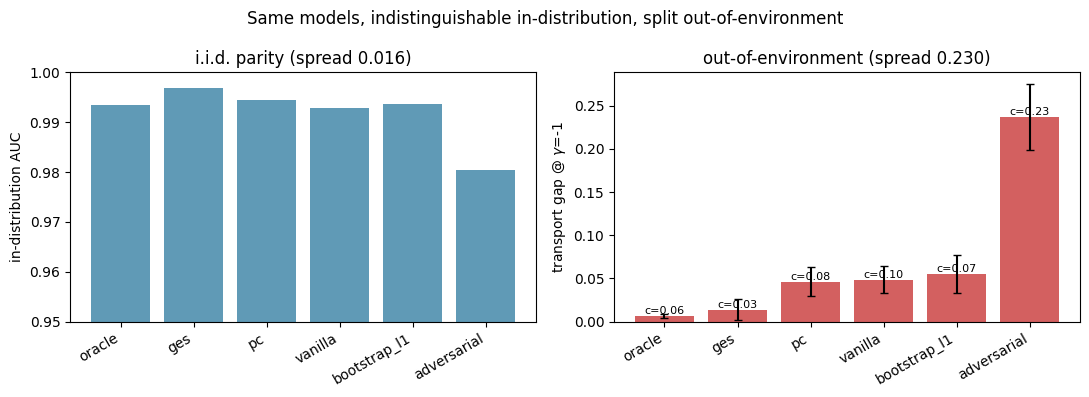

In [2]:
fig_provenance(df, ROOT / 'results/causal_prior/synthetic/recovery_shift/fig_provenance.png');

## Mechanism: transport failure is governed by correlate reliance

Pooled over all sources / seeds / densities, the transport gap is a clean monotone function of how much the fitted support relies on non-causal correlates: Pearson $r = 0.61$ at both $\gamma=0$ and $\gamma=-1$ (Spearman $0.47$ / $0.69$). A purely causal support (`correlate_inclusion` $=0$, 427 of the cells) transports with gap $\approx 0\pm0.004$; every step of correlate reliance costs out-of-environment AUC. This is the provenance-agnostic statement that parallels §6.1: it is selectivity in *support space* that buys transport, not the label “causal”.

wrote /home/yasmine/tb_internship/results/causal_prior/synthetic/recovery_shift/fig_mechanism.png


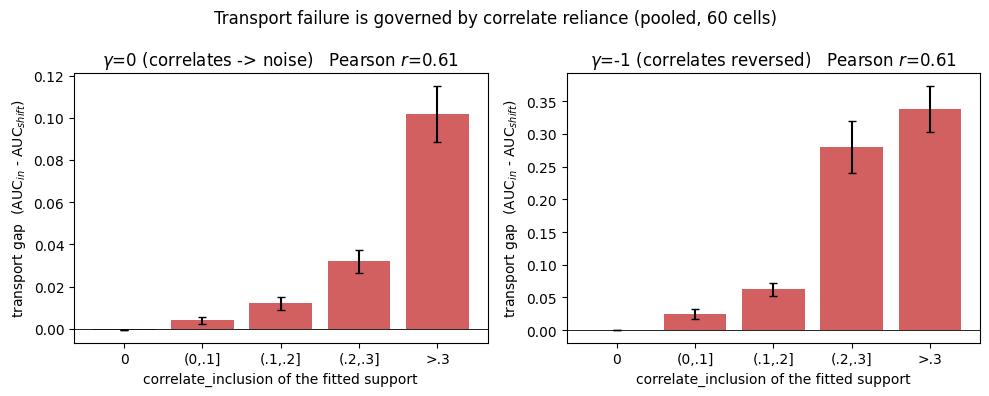

In [3]:
fig_mechanism(df, ROOT / 'results/causal_prior/synthetic/recovery_shift/fig_mechanism.png');

## Provenance → mechanism: causal discovery routes to the safe regime

The two halves join: causal discovery is the operational route to *low* correlate reliance, hence to transport. Pooled over the 60 cells at each source's operating $\mu$ (vanilla at $\mu=0$, others at $\mu_{\mathrm{rel}}=2$):

| source | in-dist AUC | correlate_inclusion | transport gap @ $\gamma{=}{-}1$ | purely-causal support |
|---|---|---|---|---|
| oracle | 0.993 | 0.063 | 0.007 | 58% |
| **ges** | 0.997 | **0.034** | **0.014** | **75%** |
| pc | 0.994 | 0.077 | 0.046 | 58% |
| vanilla | 0.993 | 0.101 | 0.049 | 47% |
| bootstrap_l1 | 0.994 | 0.066 | 0.055 | 65% |
| adversarial | 0.980 | 0.234 | 0.237 | — |

GES achieves the lowest correlate reliance and the smallest operational transport gap, and produces a purely causal support most often. The paired test below confirms the ordering is significant across the 60 cells.

In [4]:
g = df[df.test_gamma == -1.0]
def gaps(src, mu):
    return g[(g.q_source == src) & (g.mu_rel == mu)].set_index(['p_edge', 'seed'])['delta_auc']
def paired(a, b, na, nb):
    j = a.index.intersection(b.index); d = (a[j] - b[j]).dropna()
    p = wilcoxon(d, alternative='less').pvalue
    print(f'{na} - {nb}: mean {d.mean():+.4f}  Wilcoxon(less) p={p:.4f}  n={len(d)}')
paired(gaps('ges', 2.0), gaps('vanilla', 0.0), 'ges', 'vanilla')
paired(gaps('ges', 2.0), gaps('bootstrap_l1', 2.0), 'ges', 'bootstrap_l1')
paired(gaps('oracle', 2.0), gaps('vanilla', 0.0), 'oracle', 'vanilla')
paired(gaps('ges', 2.0), gaps('oracle', 2.0), 'ges', 'oracle')

ges - vanilla: mean -0.0348  Wilcoxon(less) p=0.0024  n=60
ges - bootstrap_l1: mean -0.0412  Wilcoxon(less) p=0.0227  n=60
oracle - vanilla: mean -0.0419  Wilcoxon(less) p=0.0004  n=60
ges - oracle: mean +0.0071  Wilcoxon(less) p=0.0665  n=60


ges beats vanilla ($p=0.002$) and bootstrap-$L_1$ ($p=0.023$), and is statistically indistinguishable from the oracle ($p=0.07$, i.e. not significantly worse). The median differences are near zero because most cells transport fine for every source; the gain is concentrated in the cells where a predictive shortcut exists, which is exactly where the causal prior earns its keep.

## Scope and caveats

- **What this earns.** It converts §6.1's “selectivity, not provenance” deflation into a payoff: the property that buys transport is low correlate reliance, and a causal source (GES) reaches it most reliably while a predictive source ($L_1$) and the no-prior baseline do not. The worst case (a prior deliberately peaked on confounders) collapses catastrophically, monotone in confounding density.
- **Still GES-on-Gaussian.** As in §6.1, PC contributes near-noise and is not a second surviving causal source. The operational claim rests on GES under linear-Gaussian conditions.
- **The shift is on correlate edges only.** Indirect causes live in the invariant cone, so a support that selects indirect (rather than direct) causes also transports. This is why the gap is a *low-density* effect that closes by $p_\mathrm{edge}\ge0.3$ (the correlate set shrinks), mirroring the `correlate_inclusion` curve in §6.1 — the same axis governs confounder avoidance and transport advantage.
- **Magnitudes are modest on average, large where it matters.** Means are pulled toward zero by the many cells with purely causal supports; the bin and per-source breakdowns show the effect is real and significant where correlate reliance is non-trivial.